# 02 - NLMS Normalized Adaptive Filtering

**Standalone demo notes**

Normalized LMS (NLMS) modifies LMS by dividing the update by the current input-vector energy. The algorithm is still stochastic-gradient adaptation, but the step size becomes scale-aware.

LMS update:

$$
\mathbf{w}_{n+1} = \mathbf{w}_n + \mu e[n]\mathbf{x}[n]
$$

NLMS update:

$$
\mathbf{w}_{n+1} =
\mathbf{w}_n +
\frac{\tilde{\mu}}{\epsilon + \|\mathbf{x}[n]\|^2}
e[n]\mathbf{x}[n]
$$

The effective step size is

$$
\mu_{eff}[n] = \frac{\tilde{\mu}}{\epsilon + \|\mathbf{x}[n]\|^2}
$$

Practical note: NLMS is often easier to tune because $\tilde{\mu}$ is dimensionless and the common stability region is approximately $0 < \tilde{\mu} < 2$. This notebook includes a small LMS baseline only to make the normalization effect visible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(21)


## 1. Adaptive Line Enhancer with Changing Level

Same one-sensor setup as LMS ALE, but the signal amplitude changes over time. NLMS should need less manual step-size babysitting because it scales the update by input power.


In [2]:
N = 1200
n = np.arange(N)
envelope = 0.65 + 0.65 * (n / N)

desired = envelope * (
    np.sin(2 * np.pi * 0.032 * n)
    + 0.45 * np.sin(2 * np.pi * 0.078 * n)
)
noise = 0.55 * np.random.randn(N)
x = desired + noise

delay = 10
M = 16

mu_lms = 0.006
mu_tilde = 0.05
eps = 1e-6

y_lms = np.zeros(N)
e_lms = np.zeros(N)
w_lms = np.zeros(M)

y_nlms = np.zeros(N)
e_nlms = np.zeros(N)
w_nlms = np.zeros(M)
mu_eff_history = np.zeros(N)

for i in range(delay + M - 1, N):
    x_vec = x[i - delay - M + 1 : i - delay + 1][::-1]

    y_lms[i] = np.dot(w_lms, x_vec)
    e_lms[i] = x[i] - y_lms[i]
    w_lms = w_lms + mu_lms * e_lms[i] * x_vec

    y_nlms[i] = np.dot(w_nlms, x_vec)
    e_nlms[i] = x[i] - y_nlms[i]
    mu_eff = mu_tilde / (np.dot(x_vec, x_vec) + eps)
    w_nlms = w_nlms + mu_eff * e_nlms[i] * x_vec
    mu_eff_history[i] = mu_eff

input_snr = 10 * np.log10(np.var(desired) / np.var(noise))
steady = slice(N // 2, None)
snr_lms = 10 * np.log10(np.var(desired[steady]) / (np.var(desired[steady] - y_lms[steady]) + 1e-12))
snr_nlms = 10 * np.log10(np.var(desired[steady]) / (np.var(desired[steady] - y_nlms[steady]) + 1e-12))

print(f'Input SNR:       {input_snr:.2f} dB')
print(f'LMS output SNR:  {snr_lms:.2f} dB')
print(f'NLMS output SNR: {snr_nlms:.2f} dB')


Input SNR:       3.01 dB
LMS output SNR:  8.51 dB
NLMS output SNR: 8.92 dB


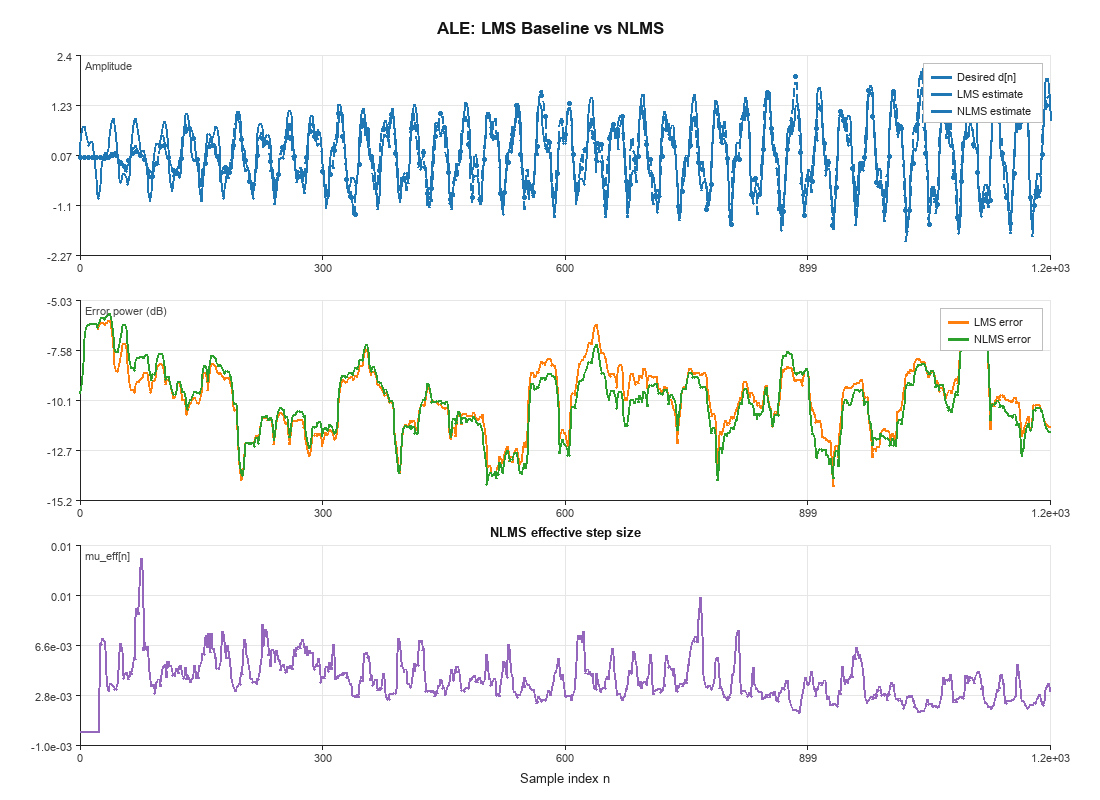

In [3]:
err_lms = np.convolve((desired - y_lms) ** 2, np.ones(35) / 35, mode='same')
err_nlms = np.convolve((desired - y_nlms) ** 2, np.ones(35) / 35, mode='same')

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle('ALE: LMS Baseline vs NLMS', fontsize=13)

axes[0].plot(n, desired, label='Desired d[n]', lw=1.5)
axes[0].plot(n, y_lms, label='LMS estimate', linestyle='--', alpha=0.8)
axes[0].plot(n, y_nlms, label='NLMS estimate', linestyle=':', alpha=0.9)
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(10 * np.log10(err_lms + 1e-12), label='LMS error', color='tab:orange')
axes[1].plot(10 * np.log10(err_nlms + 1e-12), label='NLMS error', color='tab:green')
axes[1].set_ylabel('Error power (dB)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(mu_eff_history, color='tab:purple')
axes[2].set_xlabel('Sample index n')
axes[2].set_ylabel('mu_eff[n]')
axes[2].set_title('NLMS effective step size')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 2. Feedforward Noise Cancellation with Reference-Power Changes

This section uses a reference microphone and primary microphone. The reference and primary noise both grow over time, so NLMS is a natural fit.


In [4]:
np.random.seed(12)

N = 4000
n = np.arange(N)

desired = np.sin(2 * np.pi * 0.018 * n) + 0.5 * np.sin(2 * np.pi * 0.045 * n)
noise_source = np.random.randn(N)
level = 0.55 + 0.75 * (n / N)

reference_path = np.array([1.0, 0.55, 0.25, -0.10])
primary_path = np.array([0.45, 0.20, -0.08])

x = level * np.convolve(noise_source, reference_path, mode='full')[:N]
primary_noise = level * np.convolve(noise_source, primary_path, mode='full')[:N]
d = desired + primary_noise

M = 16
mu_lms = 0.002
mu_tilde = 0.02
eps = 1e-8

y_lms = np.zeros(N)
e_lms = np.zeros(N)
w_lms = np.zeros(M)

y_nlms = np.zeros(N)
e_nlms = np.zeros(N)
w_nlms = np.zeros(M)
mu_eff_history = np.zeros(N)

for i in range(M - 1, N):
    x_vec = x[i - M + 1 : i + 1][::-1]

    y_lms[i] = np.dot(w_lms, x_vec)
    e_lms[i] = d[i] - y_lms[i]
    w_lms = w_lms + mu_lms * e_lms[i] * x_vec

    y_nlms[i] = np.dot(w_nlms, x_vec)
    e_nlms[i] = d[i] - y_nlms[i]
    mu_eff = mu_tilde / (np.dot(x_vec, x_vec) + eps)
    w_nlms = w_nlms + mu_eff * e_nlms[i] * x_vec
    mu_eff_history[i] = mu_eff

input_snr = 10 * np.log10(np.var(desired) / np.var(primary_noise))
steady = slice(N // 2, None)
snr_lms = 10 * np.log10(np.var(desired[steady]) / (np.var(desired[steady] - e_lms[steady]) + 1e-12))
snr_nlms = 10 * np.log10(np.var(desired[steady]) / (np.var(desired[steady] - e_nlms[steady]) + 1e-12))

print(f'Input SNR at primary mic: {input_snr:.2f} dB')
print(f'LMS output SNR:           {snr_lms:.2f} dB')
print(f'NLMS output SNR:          {snr_nlms:.2f} dB')


Input SNR at primary mic: 4.61 dB
LMS output SNR:           13.13 dB
NLMS output SNR:          13.92 dB


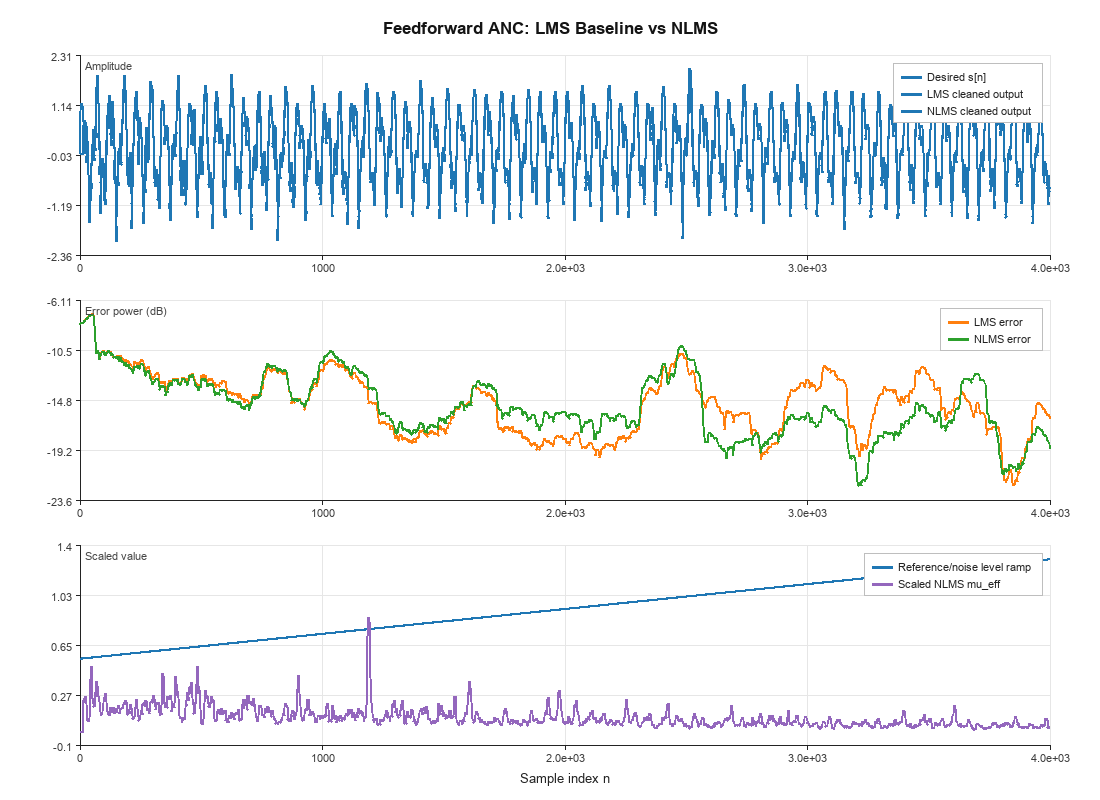

In [5]:
err_lms = np.convolve((desired - e_lms) ** 2, np.ones(100) / 100, mode='same')
err_nlms = np.convolve((desired - e_nlms) ** 2, np.ones(100) / 100, mode='same')
scaled_mu = mu_eff_history / (np.max(mu_eff_history) + 1e-12)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Feedforward ANC: LMS Baseline vs NLMS', fontsize=13)

axes[0].plot(n, desired, label='Desired s[n]', lw=1.5)
axes[0].plot(n, e_lms, label='LMS cleaned output', alpha=0.75)
axes[0].plot(n, e_nlms, label='NLMS cleaned output', alpha=0.75)
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(10 * np.log10(err_lms + 1e-12), label='LMS error', color='tab:orange')
axes[1].plot(10 * np.log10(err_nlms + 1e-12), label='NLMS error', color='tab:green')
axes[1].set_ylabel('Error power (dB)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(level, label='Reference/noise level ramp', color='tab:blue')
axes[2].plot(scaled_mu, label='Scaled NLMS mu_eff', color='tab:purple', alpha=0.75)
axes[2].set_xlabel('Sample index n')
axes[2].set_ylabel('Scaled value')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
